# StructBeat Figure 1: exact-data reproduction

**TL;DR.** This notebook replays the finalized SMC 117/221 and selected GTZAN
decoder-contrast figures from exact held-out Beat This logits and spectrograms.
It verifies the frozen figure payload, derives every IBI from event times,
exports inspectable CSVs, and keeps one parameter cell for segment selection.

The default `payload` probability source reproduces the browser figure. Choose
`raw_logits` to plot a fresh sigmoid of the stored float32 logits; the notebook
asserts that the only difference is five-decimal JSON rounding.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, IFrame, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "figure1.py").exists():
    raise RuntimeError("Run this notebook from the reproduction bundle root.")
sys.path.insert(0, str(ROOT / "src"))

from figure1 import (
    CASES,
    build_manifest,
    export_case_tables,
    load_case,
    plot_figure,
    plot_spectrogram,
    save_audio_segment,
)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "regular",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

## Parameters

Edit this single cell to move the visible/audio window. `AUDIO_OVERRIDE` may
point to an authorized WAV, FLAC, MP3, or OGG file matching the chosen item.

In [2]:
CASE_NAME = "smc_117"       # See CASES for SMC and selected GTZAN options
WINDOW_START = None          # None uses the frozen recommended window
WINDOW_SECONDS = 18.0
PROBABILITY_SOURCE = "payload"  # "payload" or "raw_logits"
SHOW_LOCAL_TAU = True
AUDIO_OVERRIDE = None        # e.g. Path("/authorized/path/smc_117.wav")
EXPORT_AUDIO_CLIP = False

assert CASE_NAME in CASES

## Load and audit the source chain

The checks below require matching piece IDs, frame counts, GT arrays, and
sigmoid(logit) probabilities. The frozen HTML payload stores probabilities at
five decimal places, so its maximum allowed reconstruction error is 5.1e-6.

In [3]:
bundle = load_case(ROOT, CASE_NAME)
payload = bundle["payload"]
if WINDOW_START is None:
    WINDOW_START = float(payload["recommended_window_start"])

audit = {
    "case": CASE_NAME,
    "piece": payload["piece"],
    "fold": payload["protocol"]["fold"],
    "role": payload["protocol"]["role"],
    "frames": int(bundle["raw"]["beat_logits"].size),
    "spectrogram_shape": list(bundle["spectrogram"].shape),
    "beat_logit_range": [float(bundle["raw"]["beat_logits"].min()), float(bundle["raw"]["beat_logits"].max())],
    "probability_rounding_error": bundle["rounding_error"],
    "window_seconds": [WINDOW_START, WINDOW_START + WINDOW_SECONDS],
}
print(json.dumps(audit, indent=2))

{
  "case": "smc_117",
  "piece": "smc/smc_117/track.npy",
  "fold": "fold 5",
  "role": "held-out test piece",
  "frames": 2001,
  "spectrogram_shape": [
    2001,
    128
  ],
  "beat_logit_range": [
    -6.4921875,
    3.669921875
  ],
  "probability_rounding_error": {
    "beat_probability_max_abs": 4.994251965331764e-06,
    "downbeat_probability_max_abs": 4.994251965331764e-06
  },
  "window_seconds": [
    21.48,
    39.480000000000004
  ]
}


## Reproduce Figure 1

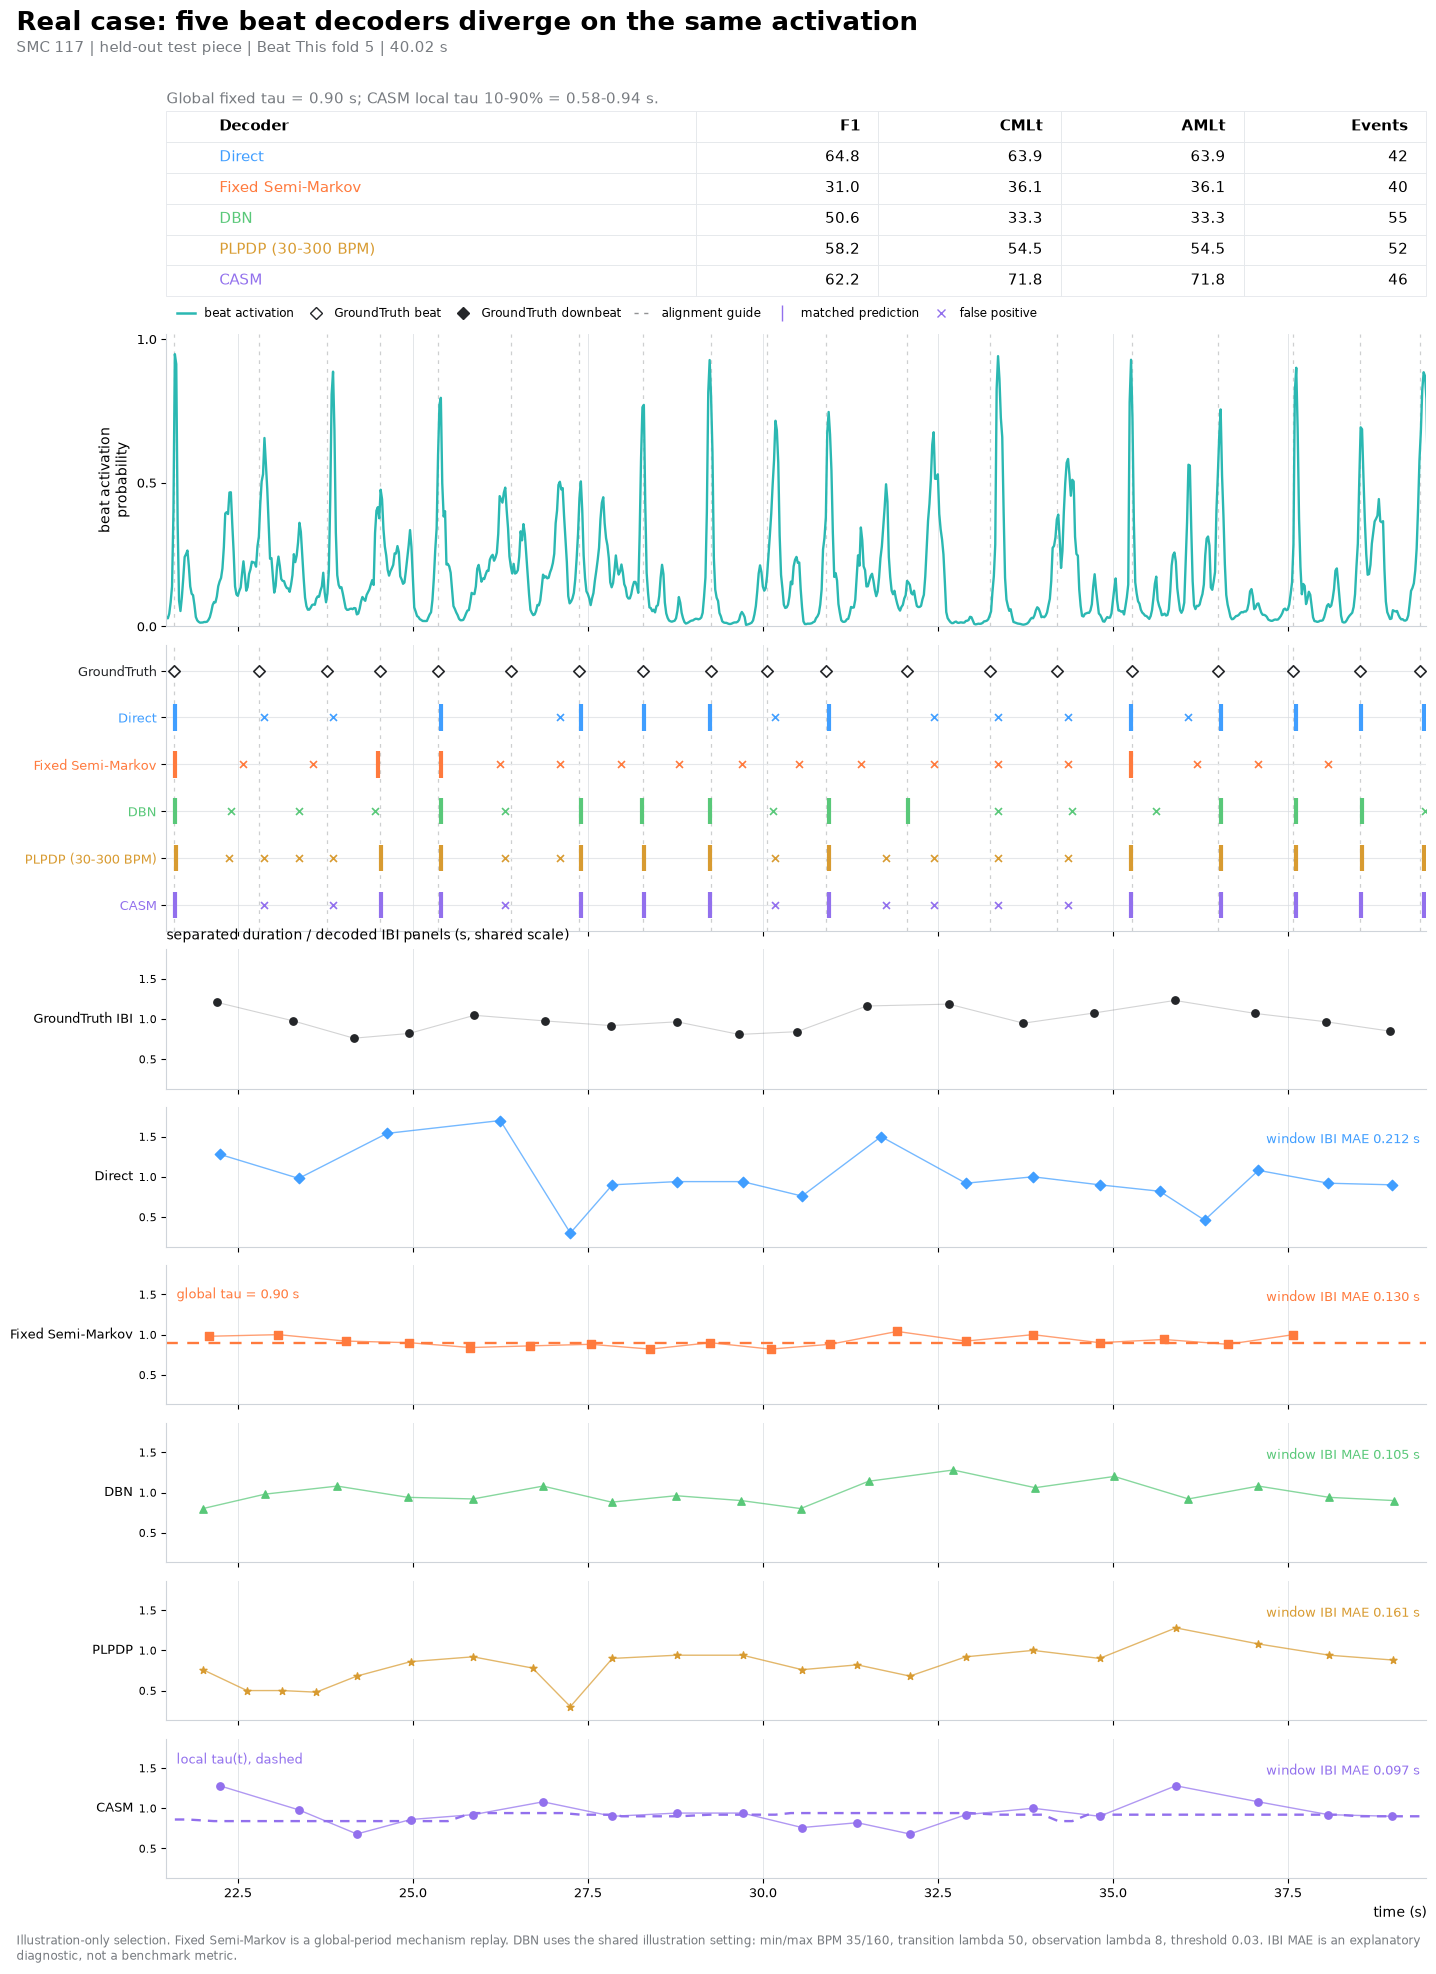

Wrote /Users/jollibear/Documents/icassp2027casm/self-run-figures/figure1-20260902-1210/outputs/figure1_smc_117.png
Wrote /Users/jollibear/Documents/icassp2027casm/self-run-figures/figure1-20260902-1210/outputs/figure1_smc_117.pdf
Window IBI MAE: {
  "direct": 0.21163444443963114,
  "fixed_semimarkov": 0.13018814856007171,
  "dbn": 0.10548732021172251,
  "plpdp": 0.16145840247829485,
  "casm": 0.0971100298278904
}


In [4]:
figure_path = ROOT / "outputs" / f"figure1_{CASE_NAME}.png"
fig, selected = plot_figure(
    bundle,
    start=WINDOW_START,
    duration=WINDOW_SECONDS,
    probability_source=PROBABILITY_SOURCE,
    show_local_tau=SHOW_LOCAL_TAU,
    output_path=figure_path,
)
figure_pdf_path = figure_path.with_suffix(".pdf")
fig.savefig(figure_pdf_path, bbox_inches="tight", facecolor="white")
display(fig)
plt.close(fig)
print("Wrote", figure_path)
print("Wrote", figure_pdf_path)
print("Window IBI MAE:", json.dumps(selected["window_mae"], indent=2))

## Inspect the exact model input

This is the unaugmented 128-bin Beat This input. SMC cases contain 2,001 frames
and GTZAN cases 1,501 frames; both use the same 50 fps clock as Figure 1.

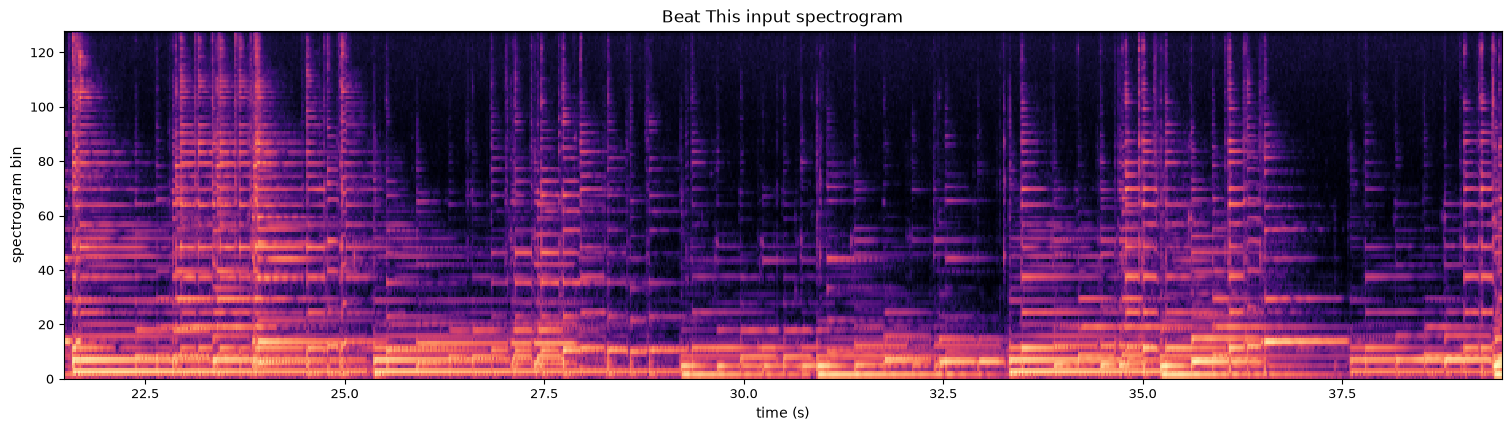

In [5]:
spec_figure = plot_spectrogram(bundle, WINDOW_START, WINDOW_SECONDS)
display(spec_figure)
plt.close(spec_figure)

## Optional waveform playback and clip export

The numerical bundle contains spectrograms rather than waveform audio. Set
`AUDIO_OVERRIDE` to a matching authorized local file; this cell then
plays exactly `[WINDOW_START, WINDOW_START + WINDOW_SECONDS]` and can export it.

In [6]:
if AUDIO_OVERRIDE is None:
    print("No waveform bundled. Set AUDIO_OVERRIDE to enable aligned playback.")
else:
    export_path = ROOT / "outputs" / f"{CASE_NAME}_{WINDOW_START:.2f}_{WINDOW_SECONDS:.2f}s.wav" if EXPORT_AUDIO_CLIP else None
    audio, sample_rate = save_audio_segment(
        AUDIO_OVERRIDE,
        WINDOW_START,
        WINDOW_SECONDS,
        output_path=export_path,
    )
    display(Audio(audio, rate=sample_rate))
    if export_path is not None:
        print("Wrote", export_path)

No waveform bundled. Set AUDIO_OVERRIDE to enable aligned playback.


## Export all events, IBIs, priors, and checksums

IBIs are derived directly from consecutive event times, not copied from a
plot. The manifest records SHA-256 checksums for every data artifact.

In [7]:
all_written = []
for case in CASES:
    case_bundle = load_case(ROOT, case)
    all_written.extend(export_case_tables(case_bundle, ROOT / "data" / "tables"))
    case_png = ROOT / "outputs" / f"figure1_{case}.png"
    case_figure, _ = plot_figure(case_bundle, output_path=case_png)
    case_figure.savefig(case_png.with_suffix(".pdf"), bbox_inches="tight", facecolor="white")
    plt.close(case_figure)
manifest = build_manifest(ROOT)
print("Exported tables:")
for path in all_written:
    print(" -", path.relative_to(ROOT))
print("Manifest files:", len(manifest["files"]))

Exported tables:
 - data/tables/smc_117_events.csv
 - data/tables/smc_117_ibi.csv
 - data/tables/smc_117_priors.csv
 - data/tables/smc_221_events.csv
 - data/tables/smc_221_ibi.csv
 - data/tables/smc_221_priors.csv
 - data/tables/gtzan_blues_00023_events.csv
 - data/tables/gtzan_blues_00023_ibi.csv
 - data/tables/gtzan_blues_00023_priors.csv
 - data/tables/gtzan_metal_00026_events.csv
 - data/tables/gtzan_metal_00026_ibi.csv
 - data/tables/gtzan_metal_00026_priors.csv
 - data/tables/gtzan_pop_00053_events.csv
 - data/tables/gtzan_pop_00053_ibi.csv
 - data/tables/gtzan_pop_00053_priors.csv
Manifest files: 31


## Rebuild the exact browser figure

This executes the preserved source builder against the frozen payloads. The
output is the exact D3 implementation used for the interactive figure, with a
case selector and draggable time-window slider.

In [8]:
browser_output = ROOT / "outputs" / "real-decoder-contrast.html"
subprocess.run(
    [
        sys.executable,
        str(ROOT / "reference" / "build_decoder_contrast_visualization.py"),
        "--smc221", str(ROOT / "data" / "figure_payloads" / "smc_221.json"),
        "--smc117", str(ROOT / "data" / "figure_payloads" / "smc_117.json"),
        "--gtzan-blues", str(ROOT / "data" / "figure_payloads" / "gtzan_blues_00023.json"),
        "--gtzan-metal", str(ROOT / "data" / "figure_payloads" / "gtzan_metal_00026.json"),
        "--gtzan-pop", str(ROOT / "data" / "figure_payloads" / "gtzan_pop_00053.json"),
        "--output", str(browser_output),
    ],
    check=True,
)
print("Wrote", browser_output)
display(IFrame(src="outputs/real-decoder-contrast.html", width="100%", height=1100))

/Users/jollibear/Documents/icassp2027casm/self-run-figures/figure1-20260902-1210/outputs/real-decoder-contrast.html
Wrote /Users/jollibear/Documents/icassp2027casm/self-run-figures/figure1-20260902-1210/outputs/real-decoder-contrast.html


## Validation notes

- SMC has beat annotations but no reference downbeat labels in this protocol;
  its GroundTruth diamonds are hollow. GTZAN also shows filled downbeat diamonds.
- PLPDP is the released algorithm with its default 30-300 BPM range.
- The two SMC examples use the shared illustration-tuned DBN. GTZAN uses the
  matched 30-300 BPM benchmark configuration.
- All displayed cases are post-hoc mechanism illustrations, not an unbiased
  estimate of aggregate benchmark performance.
- IBI curves compare local spacings and can look close despite phase-shifted or
  inserted/deleted beat events. Use F1/CMLt/AMLt for formal evaluation.